<a href="https://colab.research.google.com/github/divyansshu/pytorch/blob/main/MNIST_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    target_transform=None,
    download=True
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.08MB/s]


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
img, label = train_data[1]
img.shape, label

(torch.Size([1, 28, 28]), 0)

In [6]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
class_idx = train_data.class_to_idx
class_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

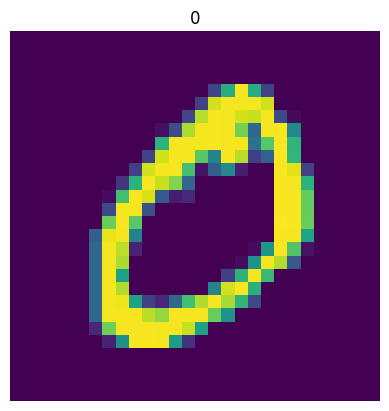

In [8]:
plt.imshow(img.squeeze())
plt.title(label)
plt.axis('off')

In [9]:
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [10]:
print(f'length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}')
print(f'length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}')

length of train dataloader: 1875 batches of 32
length of test dataloader: 313 batches of 32


In [11]:
train_features, train_labels = next(iter(train_dataloader))
train_features.shape, train_labels.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [41]:
class MNIST_Dataset(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=490, out_features=output_shape)
    )

  def forward(self, x):
    # print(f'feature map shape before passing to conv layers: {x.shape}')
    x = self.conv_block_1(x)
    # print(f'feature map shape after conv layer 1: {x.shape}')
    x = self.conv_block_2(x)
    # print(f'feature map shape after conv layer 2: {x.shape}')
    x = self.classifier(x)
    # print(f'feature map shape after classifier: {x.shape}')
    return x


In [42]:
model_1 = MNIST_Dataset(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
model_1

MNIST_Dataset(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [43]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [47]:
def accuracy(pred, actual):
  correct = torch.eq(pred, actual).sum().item()
  acc = (correct / len(pred)) * 100
  return acc

In [48]:
epochs = 5
for epoch in range(epochs):
  print(f'----------epoch: {epoch}-----------\n')
  train_loss = 0
  train_acc = 0
  for X, y in train_dataloader:
    model_1.train()
    X, y = X.to(device), y.to(device)
    y_preds = model_1(X)
    loss = loss_fn(y_preds, y)
    train_loss += loss
    train_acc += accuracy(y_preds.argmax(dim=1), y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss = train_loss / len(train_dataloader)

  with torch.inference_mode():
    test_loss = 0
    test_acc = 0
    model_1.eval()
    for X, y in test_dataloader:
      X, y = X.to(device), y.to(device)
      test_preds = model_1(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy(test_preds.argmax(dim=1), y)
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f'Train loss: {train_loss:.5f} Train accuracy: {train_acc:.2f}% Test loss: {test_loss:.5f} Test accuracy: {test_acc:.2f}%')






----------epoch: 0-----------

Train loss: 0.40215 Train accuracy: 161387.50% Test loss: 0.08404 Test accuracy: 97.47%
----------epoch: 1-----------

Train loss: 0.07802 Train accuracy: 182928.12% Test loss: 0.05584 Test accuracy: 98.07%
----------epoch: 2-----------

Train loss: 0.06021 Train accuracy: 184084.38% Test loss: 0.04321 Test accuracy: 98.47%
----------epoch: 3-----------

Train loss: 0.05047 Train accuracy: 184546.88% Test loss: 0.04431 Test accuracy: 98.45%
----------epoch: 4-----------

Train loss: 0.04408 Train accuracy: 184881.25% Test loss: 0.04825 Test accuracy: 98.42%


In [72]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=5):
  test_samples.append(sample)
  test_labels.append(label)


In [73]:
sample = test_samples[0]
sample.shape

torch.Size([1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

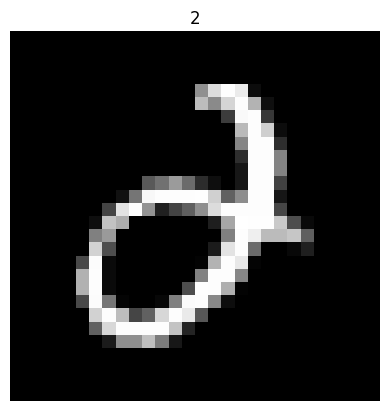

In [74]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(test_labels[0])
plt.axis('off')

In [65]:
def make_predictions(model: torch.nn.Module, samples: list, device: torch.device=device):
  preds = []
  model.eval()
  with torch.inference_mode():

    for sample in samples:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      y_logits = model(sample)
      pred_prob = torch.softmax(y_logits.squeeze(), dim=0)
      preds.append(pred_prob)
  return torch.stack(preds)


In [75]:
pred_probs = make_predictions(model_1, test_samples)
pred_probs[:1]

tensor([[1.3022e-03, 3.4227e-09, 9.9867e-01, 2.7125e-05, 1.2940e-07, 1.2638e-10,
         6.1857e-10, 1.0070e-06, 9.4951e-07, 5.1231e-07]])

In [76]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 8, 8, 9, 6])

In [77]:
test_labels

[2, 8, 8, 9, 6]

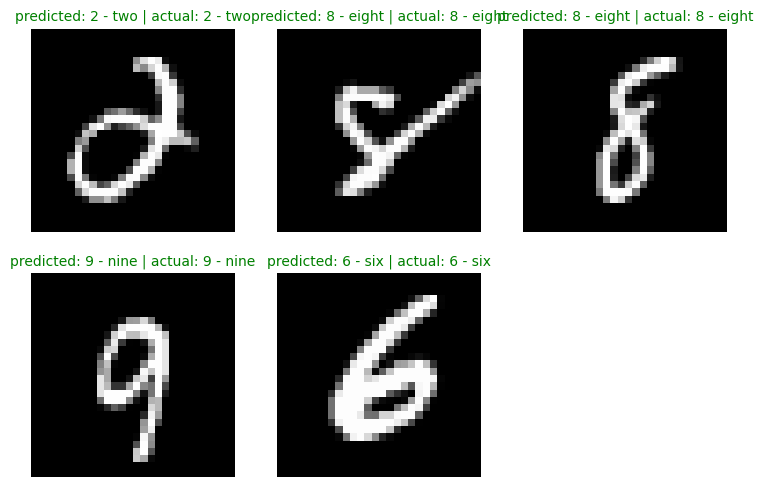

In [79]:
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze() ,cmap='gray')
  pred_label = class_names[pred_classes[i]]
  actual_label = class_names[test_labels[i]]
  title = f'predicted: {pred_label} | actual: {actual_label}'

  if pred_label == actual_label:
    plt.title(title, fontsize=10, c='g')
  else:
    plt.title(title, fontsize=10, c='r')
  plt.axis('off')

In [80]:
test_preds = []
for X, y in test_dataloader:
  X, y = X.to(device), y.to(device)
  test_logits = model_1(X)
  test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
  test_preds.append(test_pred.cpu())

test_preds_tensor = torch.cat(test_preds)

In [81]:
len(test_preds_tensor)

10000

In [82]:
!pip install torchmetrics
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.3 MB/s eta 0:00:00


In [83]:
import torchmetrics, mlxtend
print(f'mlxtend version: {mlxtend.__version__}')

mlxtend version: 0.23.4


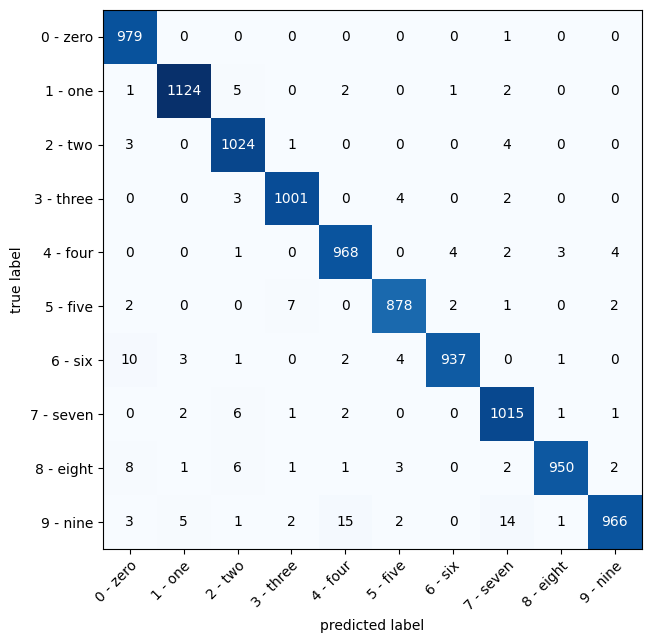

In [84]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confusion_matrix = ConfusionMatrix(num_classes = len(class_names), task='multiclass')
confusion_matrix_tensor = confusion_matrix(preds=test_preds_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confusion_matrix_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)